In [42]:
import pandas as pd
import numpy as np
import random
from typing import Set, Tuple, Dict, Any, List
from pathlib import Path
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
plt.style.use("../rw_visualization.mplstyle")

In [43]:
pkn_file = Path("../data/corrected_PKN_with_BRAF_fixes.csv")
# pkn_file = Path("../data/clean_omnipath_PKN.csv")
pkn = pd.read_csv(pkn_file)

In [44]:
pkn.head()

,source,target,interaction
0,CALM1,TRPC1,-1
1,CALM3,TRPC1,-1
2,CALM2,TRPC1,-1
3,CAV1,TRPC1,1
4,DRD2,TRPC1,1


In [45]:
def pd_to_nx(pkn: pd.DataFrame) -> nx.DiGraph:
    """Convert a pandas DataFrame to a NetworkX directed graph.

    Args:
        pkn (pd.DataFrame): DataFrame containing the data with columns 'source', 'target', and 'interaction'.

    Returns:
        nx.DiGraph: A directed graph representing the interactions.
    """
    G = nx.DiGraph()
    
    for _, row in pkn.iterrows():
        source = row['source']
        target = row['target']
        interaction = row['interaction']
        
        # Add nodes if they don't exist
        if source not in G:
            G.add_node(source)
        if target not in G:
            G.add_node(target)
        
        # Add edge with interaction attribute
        G.add_edge(source, target, interaction=interaction)
    
    return G

In [46]:
G = pd_to_nx(pkn)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 6630
Number of edges: 67368


# Modularity analysis 

In [47]:
communities_len = []
modularities = []

for seed in range(100):
    communities = nx.community.louvain_communities(G, seed=seed)
    modularity = nx.community.modularity(G, communities)
    communities_len.append(len(communities))
    modularities.append(modularity)

In [48]:
# comunity_sizes = []
# for community in communities:
#     comunity_sizes.append(len(community))

Mean modularity: 0.401
Mean number of communities: 140.8


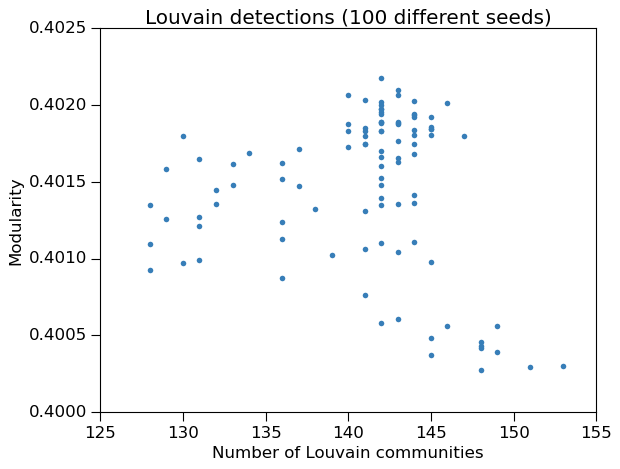

In [49]:
plt.figure()
plt.plot(communities_len, modularities, '.')
plt.xlabel("Number of Louvain communities")
plt.ylabel("Modularity")
plt.title("Louvain detections (100 different seeds)")
print(f"Mean modularity: {np.mean(modularities):.3f}")
print(f"Mean number of communities: {np.mean(communities_len):.1f}")


In [50]:
# communities = nx.community.girvan_newman(G)
# modularity = nx.community.modularity(G, communities)
# print(f"Girvan-Newman modularity: {modularity}")

In [51]:
# len(nx.community.label_propagation_communities(G.to_undirected()))

# Assortativity analysis

In [52]:
r = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity coefficient: {r:3.1f}")

Degree assortativity coefficient: 0.9


# Subgraphs (louvain_communities (seed 99)) density

In [53]:
# Get the subgraphs by communities
subgraphs = [G.subgraph(nodes) for nodes in communities]

In [54]:
# # Calculate density for each subgraph
# subgraph_densities = [nx.density(sg) for sg in subgraphs]
# plt.hist(subgraph_densities, bins=100)
# plt.xlabel("Density")
# plt.ylabel("Frequency")
# plt.show()
# print(f"Mean subgraph density: {np.mean(subgraph_densities)}")
# print(f"Max subgraph density: {np.max(subgraph_densities)}")
# print(f"Min subgraph density: {np.min(subgraph_densities)}")

In [55]:
# subgraph_num_nodes = [sg.number_of_nodes() for sg in subgraphs]
# plt.hist(subgraph_num_nodes, bins=100)
# plt.xlabel("Number of nodes")
# plt.ylabel("Frequency")
# print(f"Mean number of nodes: {np.mean(subgraph_num_nodes)}")
# print(f"Max number of nodes: {np.max(subgraph_num_nodes)}")
# print(f"Min number of nodes: {np.min(subgraph_num_nodes)}")

Text(0, 0.5, 'Density')

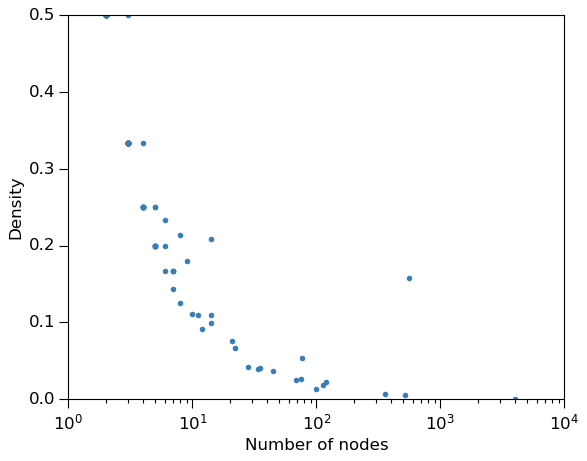

In [56]:
plt.figure()
plt.plot(subgraph_num_nodes, subgraph_densities, '.')
plt.xscale("log")
plt.xlabel("Number of nodes")
plt.ylabel("Density")

# Find densest subgraph
NOTE: This method only works on the underected graph

In [57]:
subgraph_density, subgraph_nodes = nx.approximation.densest_subgraph(G.to_undirected(), iterations=1, method='greedy++')
print(f"Number of nodes in densest subgraph: {len(subgraph_nodes)}")

Number of nodes in densest subgraph: 492


In [58]:
densest_subgraph = G.subgraph(subgraph_nodes)
print(f"Number of nodes in densest subgraph: {densest_subgraph.number_of_nodes()}")
print(f"Number of edges in densest subgraph: {densest_subgraph.number_of_edges()}")
print(f"Density of densest subgraph: {nx.density(densest_subgraph):.3f}")
print(f"Density of densest subgraph (undirected): {nx.density(densest_subgraph.to_undirected()):.3f}")

Number of nodes in densest subgraph: 492
Number of edges in densest subgraph: 48441
Density of densest subgraph: 0.201
Density of densest subgraph (undirected): 0.401


In [60]:
print(f"Density of original graph: {nx.density(G):.3f}")

Density of original graph: 0.002


In [59]:
# Check the densities for all nodes except the densest subgraph
all_nodes = set(G.nodes())
remaining_nodes = all_nodes - set(subgraph_nodes)
remaining_subgraph = G.subgraph(remaining_nodes)
print(f"Number of nodes in remaining subgraph: {remaining_subgraph.number_of_nodes()}")
print(f"Number of edges in remaining subgraph: {remaining_subgraph.number_of_edges()}")
print(f"Density of remaining subgraph: {nx.density(remaining_subgraph):.4f}")
print(f"Density of remaining subgraph (undirected): {nx.density(remaining_subgraph.to_undirected()):.5f}")

Number of nodes in remaining subgraph: 6138
Number of edges in remaining subgraph: 17967
Density of remaining subgraph: 0.0005
Density of remaining subgraph (undirected): 0.00094
